Analytical Problem

This analysis aims to build a reliable time series forecasting model to predict Superstore sales for the next 7 days. By identifying historical sales patterns, seasonal trends, and short-term fluctuations, the model will generate accurate daily sales forecasts. The results will support store managers in adjusting inventory levels, staffing plans, and promotional activities in advance.

Target User

The primary user is the store operations manager or supply chain planner, who needs short-term sales forecasts to optimize daily operations, avoid stock shortages or overstocking, and improve operational efficiency.

Dataset

Source: Kaggle (Rohit Sahoo, Sales Forecasting Dataset)
Access Date: April 2026
Key Fields: Order Date, Sales

In [1]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

df = pd.read_csv("D:/Sample - Superstore.csv", encoding="latin-1")
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


Sales Forecasting and EDA
Part 1: Exploratory Data Analysis

In [18]:
df.describe()  

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [20]:
if "Row ID" in df.columns:
    df.drop(columns="Row ID", inplace=True)

df['Order Date'] = pd.to_datetime(df['Order Date'], format="%m/%d/%Y")
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format="%m/%d/%Y")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Ship Date      9994 non-null   datetime64[ns]
 3   Ship Mode      9994 non-null   object        
 4   Customer ID    9994 non-null   object        
 5   Customer Name  9994 non-null   object        
 6   Segment        9994 non-null   object        
 7   Country        9994 non-null   object        
 8   City           9994 non-null   object        
 9   State          9994 non-null   object        
 10  Postal Code    9994 non-null   int64         
 11  Region         9994 non-null   object        
 12  Product ID     9994 non-null   object        
 13  Category       9994 non-null   object        
 14  Sub-Category   9994 non-null   object        
 15  Product Name   9994 n

In [21]:
print('Order Date Description\n') 
print(df['Order Date'].describe()) #Displays the distribution of dates in 'Order Data' column
print('\nShip Date Description\n')
print(df['Ship Date'].describe()) #Displays the distribution of dates in 'Ship Data' column

Order Date Description

count                             9994
mean     2016-04-30 00:07:12.259355648
min                2014-01-03 00:00:00
25%                2015-05-23 00:00:00
50%                2016-06-26 00:00:00
75%                2017-05-14 00:00:00
max                2017-12-30 00:00:00
Name: Order Date, dtype: object

Ship Date Description

count                             9994
mean     2016-05-03 23:06:58.571142912
min                2014-01-07 00:00:00
25%                2015-05-27 00:00:00
50%                2016-06-29 00:00:00
75%                2017-05-18 00:00:00
max                2018-01-05 00:00:00
Name: Ship Date, dtype: object


In [22]:
df.sort_values(by=['Order Date'], inplace=True, ascending=True) #Sorting data by  ascending order of the coloumn values 'Order Date'
df.set_index("Order Date", inplace = True)
new_data = pd.DataFrame(df['Sales'])
new_data

,Sales
Order Date,
2014-01-03,16.448
2014-01-04,11.784
2014-01-04,272.736
2014-01-04,3.540
2014-01-05,19.536
...,...
2017-12-30,3.024
2017-12-30,52.776
2017-12-30,90.930


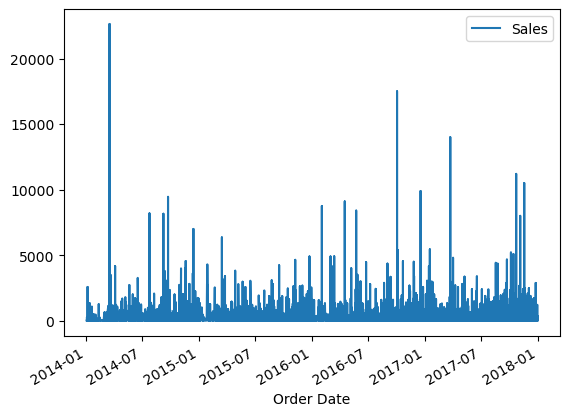

In [23]:
new_data.plot();

In [24]:
new_data =  pd.DataFrame(new_data['Sales'].resample('D').mean())
new_data = new_data.interpolate(method='linear')
from statsmodels.tsa.stattools import adfuller #importing adfuller tool from statsmodels
#statsmodels provide adfuller() fucntion to implement stationarity test of a time series

adf = adfuller(new_data) 

print(adf)
print('\nADF = ', str(adf[0])) #more towards negative value the better
print('\np-value = ', str(adf[1]))
print('\nCritical Values: ')

for key, val in adf[4].items(): #for loop to print the p-value (1%, 5% and 10%) and their respective values
    print(key,':',val)
    

    if adf[0] < val:
        print('Null Hypothesis Rejected. Time Series is Stationary')
    else:
        print('Null Hypothesis Accepted. Time Series is not Stationary')

(np.float64(-20.8760268457978), 0.0, 2, 1455, {'1%': np.float64(-3.4348523191002123), '5%': np.float64(-2.8635284734563364), '10%': np.float64(-2.567828646449617)}, np.float64(20038.51742173917))

ADF =  -20.8760268457978

p-value =  0.0

Critical Values: 
1% : -3.4348523191002123
Null Hypothesis Rejected. Time Series is Stationary
5% : -2.8635284734563364
Null Hypothesis Rejected. Time Series is Stationary
10% : -2.567828646449617
Null Hypothesis Rejected. Time Series is Stationary


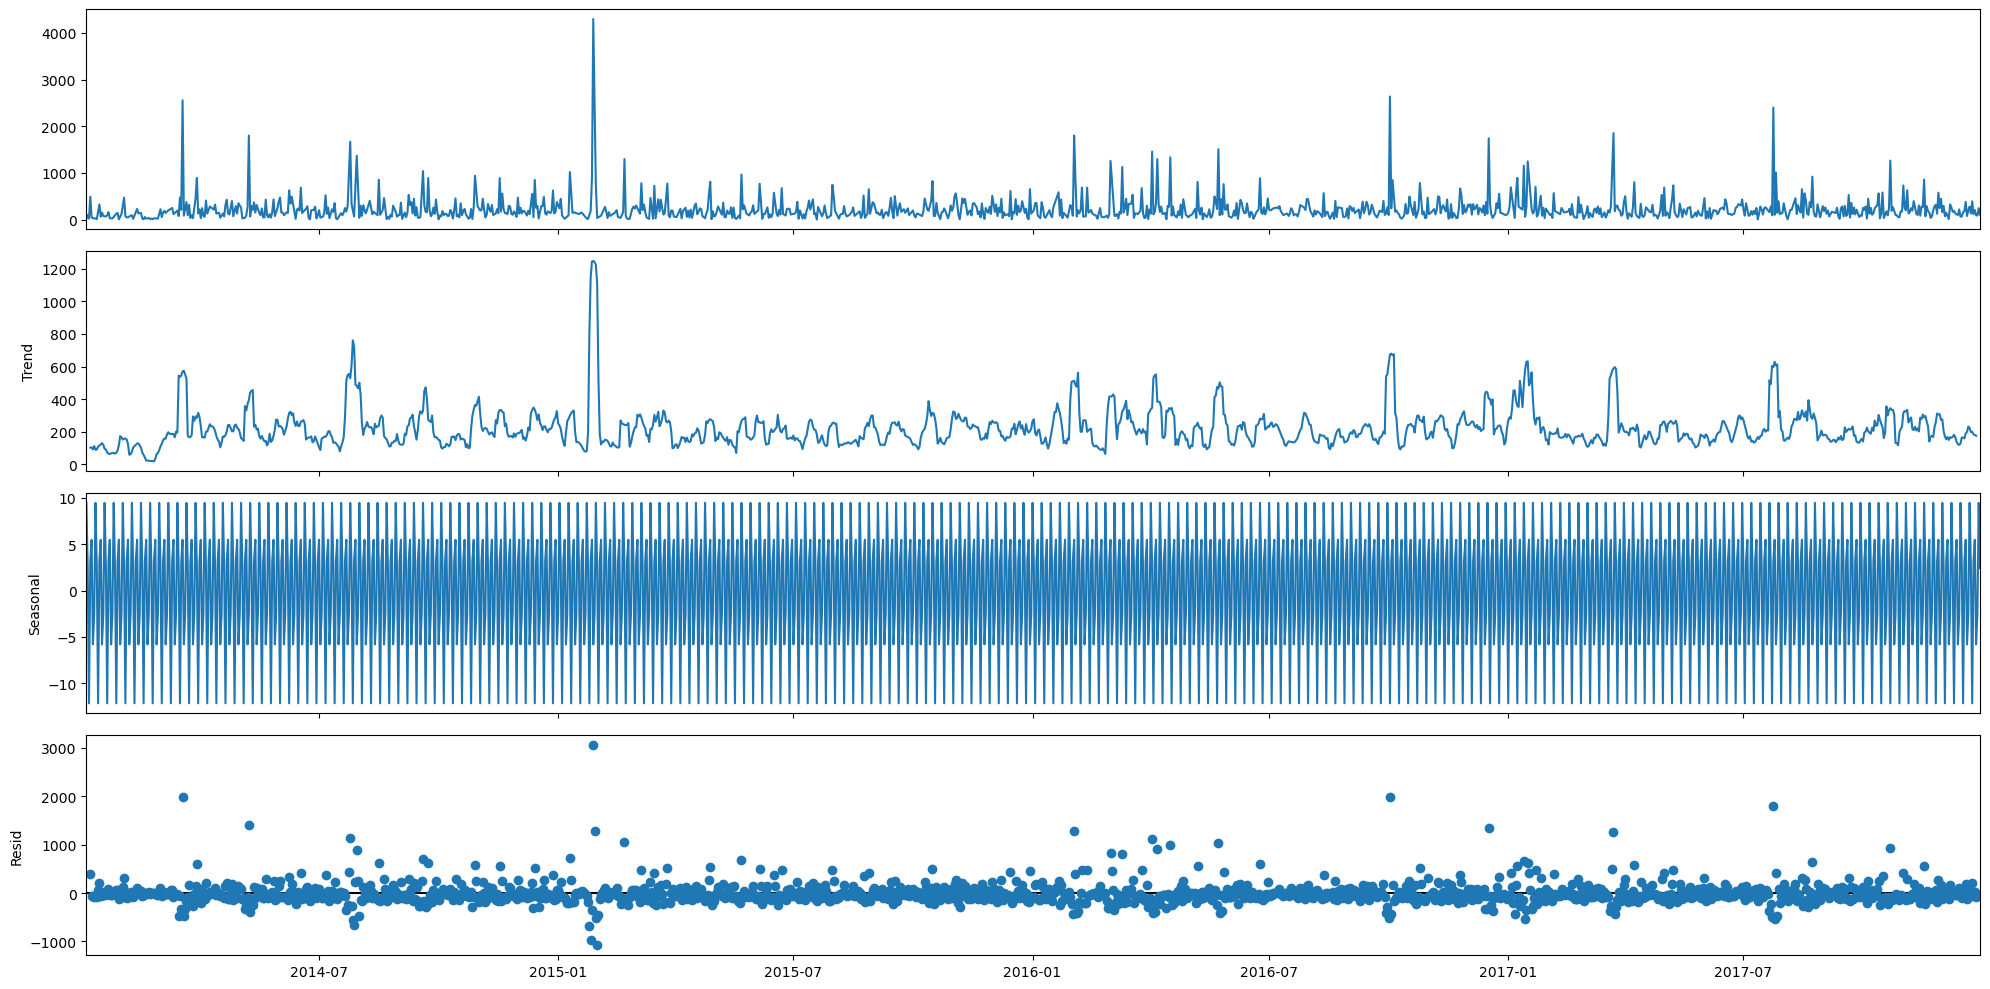

In [25]:
from pylab import rcParams
rcParams['figure.figsize'] = 20, 10

import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(new_data, model='additive') #function used to decompose Time Series Data into Trend and Seasonality
fig = decomposition.plot()
plt.show();

Now that we know our time series is data is stationary. Let us begin with model training for forecasting the sales. We have chosen SARIMA model to forecast the sales.

Seasonal Autoregressive Integrated Moving Average, SARIMA or Seasonal ARIMA, is an extension of ARIMA that supports univariate time series data with a seasonal component.

SARIMA requires selecting hyperparameters for both the trend and seasonal elements of the series.

Trend Elements There are three trend elements that require configuration. p: Trend autoregression order. d: Trend difference order. q: Trend moving average order.

Seasonal Elements There are four seasonal elements: P: Seasonal autoregressive order. D: Seasonal difference order. Q: Seasonal moving average order. m: The number of time steps for a single seasonal period.

The notation for a SARIMA model is specified as: SARIMA(p,d,q)(P,D,Q)m

In [26]:
import itertools
p = d = q = range(0, 2) 
pdq = list(itertools.product(p, d, q))
seasonal_pdq_comb = [(i[0], i[1], i[2], 12) for i in list(itertools.product(p, d, q))] #for loop for creating combinations of seasonal parameters of SARIMA
print('Examples of parameter combinations for Seasonal ARIMA:')
print('SARIMA: {} x {}'.format(pdq[1], seasonal_pdq_comb[1]))
print('SARIMA: {} x {}'.format(pdq[1], seasonal_pdq_comb[2]))
print('SARIMA: {} x {}'.format(pdq[2], seasonal_pdq_comb[3]))
print('SARIMA: {} x {}'.format(pdq[2], seasonal_pdq_comb[4]))

Examples of parameter combinations for Seasonal ARIMA:
SARIMA: (0, 0, 1) x (0, 0, 1, 12)
SARIMA: (0, 0, 1) x (0, 1, 0, 12)
SARIMA: (0, 1, 0) x (0, 1, 1, 12)
SARIMA: (0, 1, 0) x (1, 0, 0, 12)


In [27]:
import warnings
import itertools
import statsmodels.api as sm

warnings.filterwarnings("ignore")


p = d = q = range(0, 2)
pdq = list(itertools.product(p, d, q))


s = 12
P = D = Q = range(0, 2)
seasonal_pdq = [(P_val, D_val, Q_val, s) for P_val in P for D_val in D for Q_val in Q]


for parameters in pdq:
    for seasonal_param in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(
                new_data,
                order=parameters,
                seasonal_order=seasonal_param,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            results = mod.fit()
            print(f"SARIMA{parameters}{seasonal_param} - AIC:{results.aic}")
        except:
            continue

SARIMA(0, 0, 0)(0, 0, 0, 12) - AIC:21189.20368984832
SARIMA(0, 0, 0)(0, 0, 1, 12) - AIC:20885.049528250915
SARIMA(0, 0, 0)(0, 1, 0, 12) - AIC:21318.658935551088
SARIMA(0, 0, 0)(0, 1, 1, 12) - AIC:20157.342166197253
SARIMA(0, 0, 0)(1, 0, 0, 12) - AIC:20805.305371140304
SARIMA(0, 0, 0)(1, 0, 1, 12) - AIC:20334.378747464034
SARIMA(0, 0, 0)(1, 1, 0, 12) - AIC:20686.173443923937
SARIMA(0, 0, 0)(1, 1, 1, 12) - AIC:20157.549510842364
SARIMA(0, 0, 1)(0, 0, 0, 12) - AIC:20876.87966884731
SARIMA(0, 0, 1)(0, 0, 1, 12) - AIC:20651.520419666704
SARIMA(0, 0, 1)(0, 1, 0, 12) - AIC:21244.108222966937
SARIMA(0, 0, 1)(0, 1, 1, 12) - AIC:20086.68343381357
SARIMA(0, 0, 1)(1, 0, 0, 12) - AIC:20641.810499934203
SARIMA(0, 0, 1)(1, 0, 1, 12) - AIC:20254.339978072934
SARIMA(0, 0, 1)(1, 1, 0, 12) - AIC:20625.98240628984
SARIMA(0, 0, 1)(1, 1, 1, 12) - AIC:20087.01997403279
SARIMA(0, 1, 0)(0, 0, 0, 12) - AIC:21074.396498723832
SARIMA(0, 1, 0)(0, 0, 1, 12) - AIC:20908.677384027233
SARIMA(0, 1, 0)(0, 1, 0, 12) - AI

In [28]:
mod = sm.tsa.statespace.SARIMAX(new_data,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False) #model defintion
results = mod.fit() #model fitting
print(results.summary().tables[1]) # displaying the result 

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2151      0.011     20.295      0.000       0.194       0.236
ma.L1         -1.0000     10.233     -0.098      0.922     -21.057      19.057
ar.S.L12      -0.0341      0.034     -0.990      0.322      -0.102       0.033
ma.S.L12      -1.0000     10.239     -0.098      0.922     -21.068      19.068
sigma2      6.914e+04      0.000   4.64e+08      0.000    6.91e+04    6.91e+04


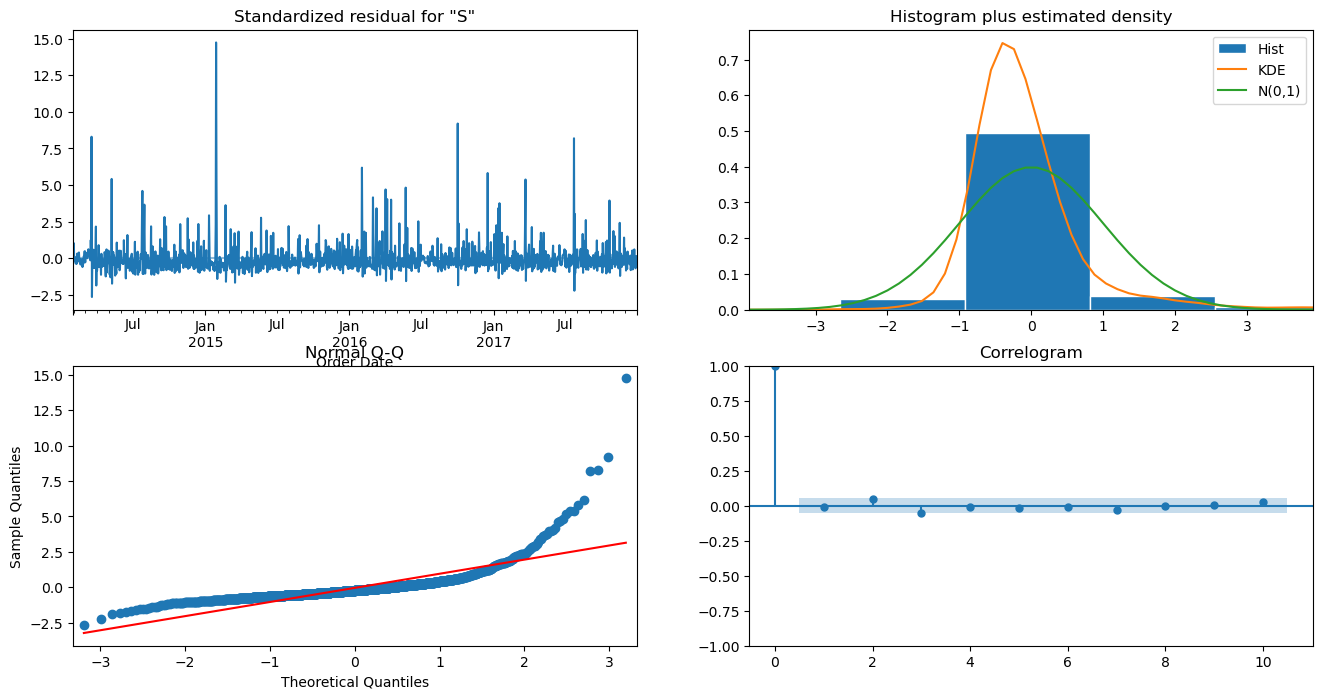

In [29]:
results.plot_diagnostics(figsize=(16, 8)) #Produces a plot grid of: 1. Standardized residuals over time 
# 2. Histogram plus estimated density of standardized residulas and along with a Normal(0,1) density plotted for reference.
# 3. Normal Q-Q plot, with Normal reference line and, 4. Correlogram.
plt.show()

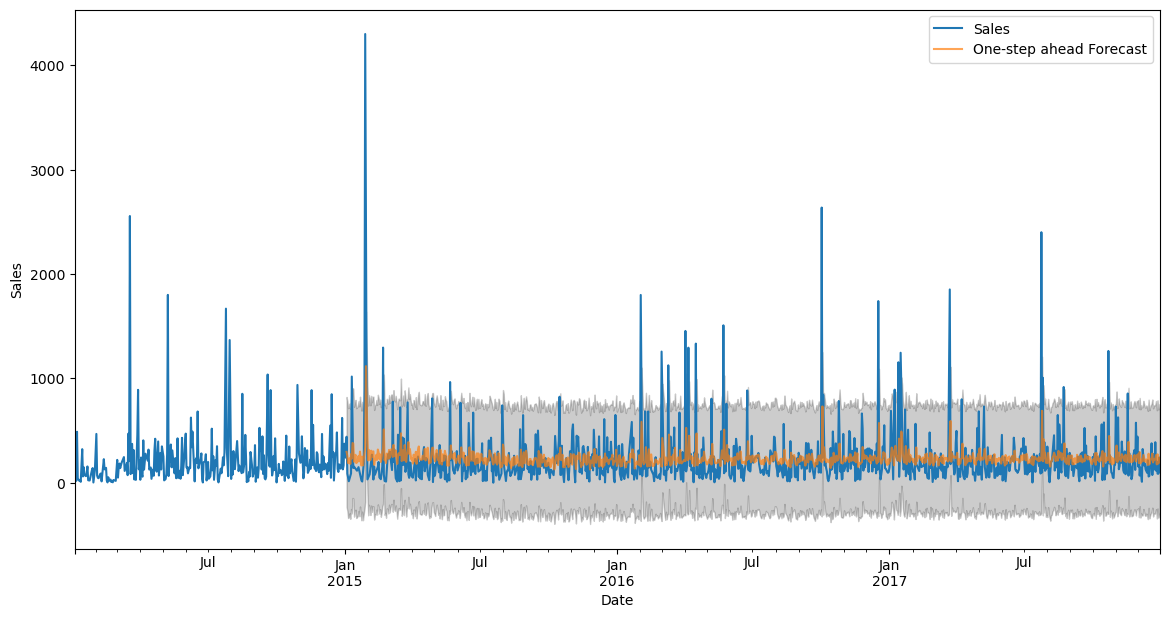

In [30]:
pred = results.get_prediction(start=pd.to_datetime('2015-01-03'), dynamic=False) # variable to display plot for predicted values
pred_val = pred.conf_int()
ax = new_data['2014':].plot(label='observed') # displays plot for original values
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7)) # displays plot for predicted values
ax.fill_between(pred_val.index,
                pred_val.iloc[:, 0],
                pred_val.iloc[:, 1], color='k', alpha=.2)
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
plt.legend()
plt.show()

In [31]:
y_forecasted = pred.predicted_mean
y_truth = new_data['Sales']

from sklearn.metrics import mean_squared_error
from math import sqrt


if len(y_forecasted) != len(y_truth):
    min_len = min(len(y_forecasted), len(y_truth))
    y_forecasted = y_forecasted[-min_len:]
    y_truth = y_truth[-min_len:]

mse = mean_squared_error(y_truth, y_forecasted)
rmse = sqrt(mse)
print(f'The Root Mean Squared Error of the forecasts is {round(rmse, 2)}')

The Root Mean Squared Error of the forecasts is 269.87


Out of Sample forecast:

To forecast sales values after some time period of the given data. In our case, we have to forecast sales with time period of 7 days.

In [32]:
# mod = sm.tsa.statespace.SARIMAX(new_data,
#                                 order=(1, 1, 1),
#                                 seasonal_order=(1, 1, 1, 12),
#                                 enforce_stationarity=False,
#                                 enforce_invertibility=False) #model defintion
# results = mod.fit() #model fitting

forecast = results.forecast(steps=7) # making a forecast of 7 days later of the last date in the 'Order Date' column
print(forecast.astype('int')) #displays the sales forecast as type integer

2017-12-31    223
2018-01-01    250
2018-01-02    230
2018-01-03    228
2018-01-04    210
2018-01-05    241
2018-01-06    233
Freq: D, Name: predicted_mean, dtype: int64


In [33]:
forecast = forecast.astype('int') #saving the sales values as type integer
forecast_df = forecast.to_frame() # forecast is in Series form, converting it to DataFrame
forecast_df.reset_index(level=0, inplace=True) # converting the index to column
forecast_df.columns = ['Prediction Date', 'Predicted Sales'] # giving appropriate names to the output columns
prediction = pd.DataFrame(forecast_df).to_csv('prediction.csv',index=False) # saving the output as a csv file with name 'prediction.csv'